# <center> VISU Inférences </center>

In [1]:
import random
from functools import partial
from omegaconf import DictConfig
import os
import torch
import rasterio
import numpy as np
from pathlib import Path
import h5py
from typing import Dict, Any
import matplotlib.pyplot as plt
from omegaconf import OmegaConf
from lib import config_utils
from lib import data_utils
from lib import visutils # gallery / apply_brightness_factor / sequence2gallery 

from lib.eval_tools import (
    Imputation,
    visualize_att_for_one_head_across_time,
    visualize_att_for_target_t_across_heads
)
from run_train import setup_logging, setup_datasets, setup_data_loaders
from dataloader_CIRCA.datasets import CIRCA_ADAPTED2UTILISE_Dataset
from lib.data_utils import pad_collate
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)   # ou FutureWarning, UserWarning, ...

In [2]:
def get_sample(
    dataloader: torch.utils.data.dataloader.DataLoader,
    sample_index: int
) -> Dict[str, Any]:
    
    batch = dataloader.dataset.__getitem__(sample_index)
    
    # Introduce the batch dimension (required for the forward pass)
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0)
        elif isinstance(v, int):
            batch[k] = [v]

    return batch

In [3]:
# Setup configuration
config_file = Path("./configs/config_run_train.yaml")
default_config_path = Path("./configs/default.yaml")
cfg_custom = config_utils.read_config(config_file)
cfg_default = config_utils.read_config(default_config_path)
config = OmegaConf.merge(cfg_default, cfg_custom)

In [4]:
# Faire différents changments dans les fichiers de configs pour les vérifications
config.data.hdf5_file = "/DATA_10TB/data_rpg/circa/hdf5/CIRCA_CR_merged.hdf5"
config.mask.mask_type = 'random_fully_masked'
config.data.max_seq_length = None
config.training_settings.batch_size = 10
config.mask.ratio_masked_frames = 0.8
config.mask.intersect_real_cloud_masks = False
config.mask.dilate_cloud_masks = False
# !!! Mettre un ratio_masked_frames plus petit que 0.5 dans le cas fully_masked aléatoire

BRIGHTNESS_FACTOR = 3
# Setup logging
logger = setup_logging(config)

# Génération des dataset
phase = "test"
dset = data_utils.get_dataset(config, phase=phase, logger=logger)
# num_samples_demo = 5
# idx_samples = np.arange(num_samples_demo)
# # idx_samples = np.random.choice(np.arange(len(dset)), num_samples_demo)
# for i in idx_samples:
#     sample = dset[i]
#     fig = visutils.sequence2gallery(
#         sample['x'], 
#         indices_rgb=sample['c_index_rgb'], 
#         brightness_factor=BRIGHTNESS_FACTOR,
#     )
#     plt.title(f'Sample {i + 1} - X - Mask type {config.mask.mask_type}', fontsize=7)
#     fig = visutils.sequence2gallery(
#         sample['y'], 
#         indices_rgb=sample['c_index_rgb'], 
#         brightness_factor=BRIGHTNESS_FACTOR,
#     )
#     plt.title(f'Sample {i + 1} - Y - Mask type {config.mask.mask_type}', fontsize=7)

In [5]:
from lib.eval_tools import Imputation
from lib import config_utils

path_inference_config_file = Path("/home/SPeillet/cloud_reconstruction/U-TILISE/configs/config_run_eval.yaml")

# Modèle ALL_BANDS sans SAR
# path_ckpt_config_file = Path("/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_BANDS_120_epochs_2025-07-11_18-05/config.yaml")
# path_ckpt_pth = Path("/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_BANDS_120_epochs_2025-07-11_18-05/checkpoints/Model_best.pth")

# Modèle ALL_BANDS avec SAR
path_ckpt_config_file = Path("/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/config.yaml")
path_ckpt_pth = Path("/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/checkpoints/Model_best.pth")

training_config_file = config_utils.read_config(path_ckpt_config_file)
inference_config_file = config_utils.read_config(path_inference_config_file)

inference_imputation = Imputation(
    config_file_train=path_inference_config_file, # Config permettant de faire la configuration de l'inference
    method="utilise",
    checkpoint=path_ckpt_pth,
    config_file_test=path_ckpt_config_file, # Fichier ayant servi à l'entrainement du modèle (update params model)
)

Checkpoint '/DATA_10TB/data_rpg/outputs/U-TILISE/results/ALL_SAR_120_epochs_2025-07-11_16-56/checkpoints/Model_best.pth' loaded.
Chosen epoch: 109



In [6]:
# Setup data loader
subset = config.data.get("subset", False)
if subset and isinstance(config.data.subset, bool):
    subset = 10

generator = torch.Generator()
generator.manual_seed(config.misc.get("random_seed", 42))

data_loader = data_utils.get_dataloader(
    dset,
    config,
    drop_last=False,
    shuffle=False,
    generator=generator,
    subset=subset,
)

Text(0.5, 1.0, 'U-TILISE imputation')

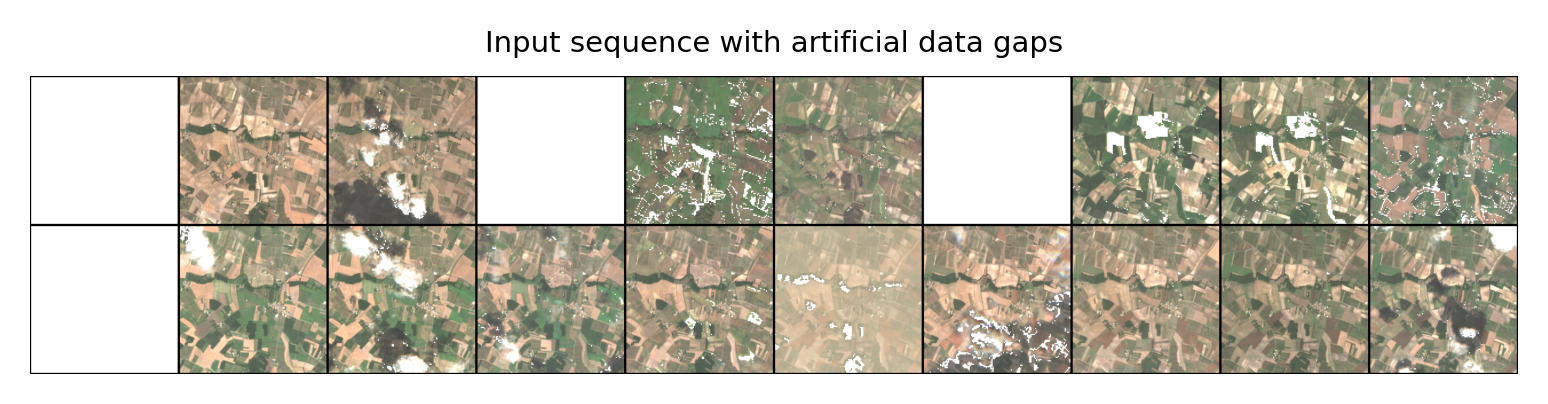

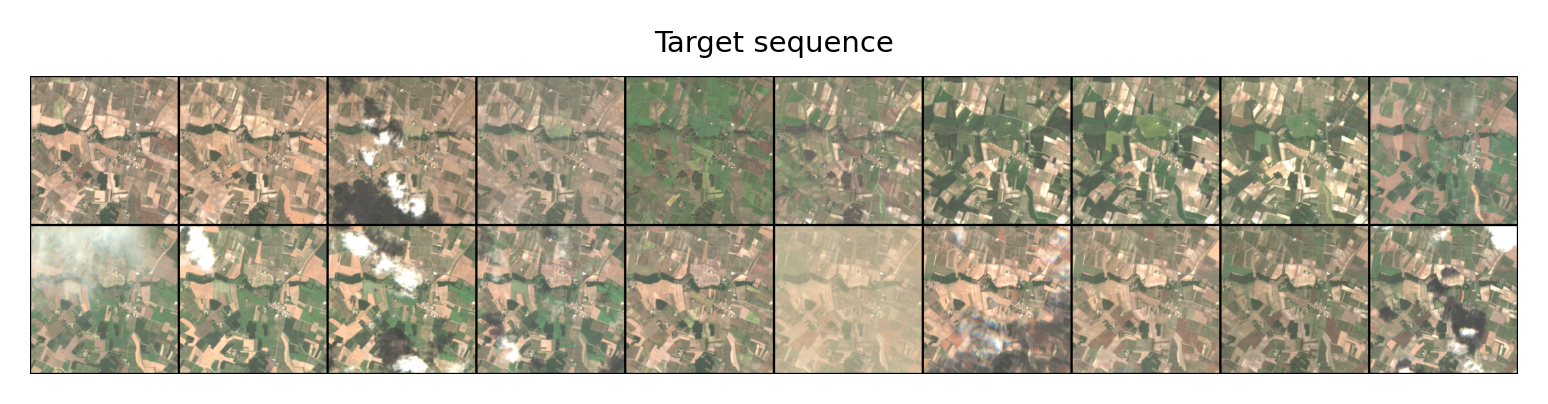

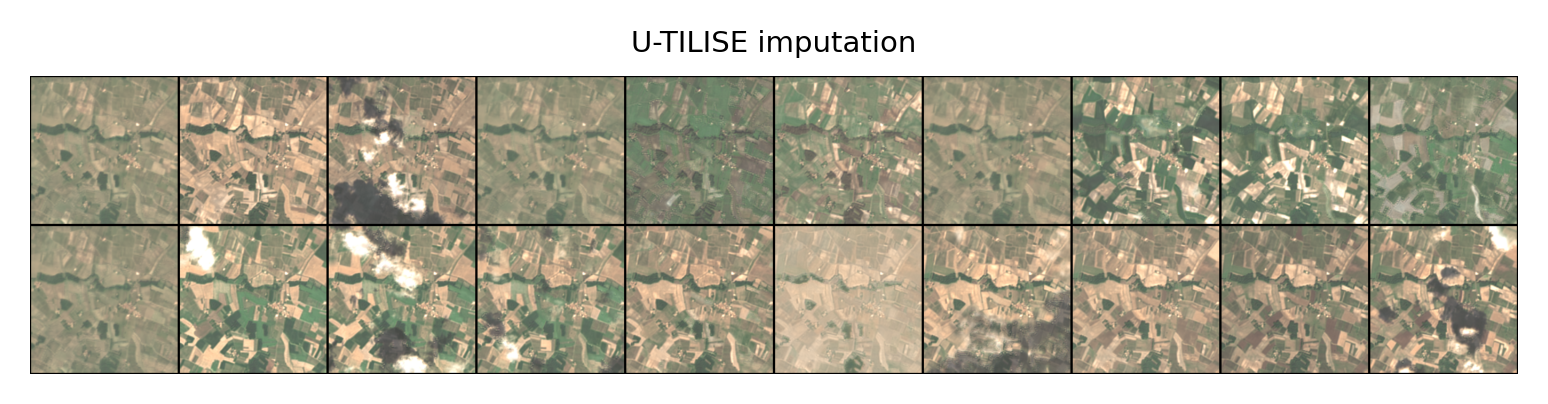

In [7]:
index = 75 
sample = get_sample(data_loader, index)
batch, y_pred, att = inference_imputation.impute_sample(
    batch=sample,
    # t_start=0,
    # t_end=10,
    return_att=True,
)

# Let's visualize the sequences
brightness_factor = 3
indices_rgb = batch['c_index_rgb'][0]

fig = visutils.sequence2gallery(batch['x'][0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('Input sequence with artificial data gaps', fontsize=7)

fig = visutils.sequence2gallery(batch['y'][0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('Target sequence', fontsize=7)

fig = visutils.sequence2gallery(y_pred[0], indices_rgb=indices_rgb, brightness_factor=brightness_factor)
plt.title('U-TILISE imputation', fontsize=7)


In [10]:
# Ajout calcul de métriques
from dataloader_CIRCA.datasets.cr_metrics import CloudRemovalMetrics, display_metrics

cr_metrics = CloudRemovalMetrics(
    eval_occluded_observed=True,
    clean_gt_cloudy_pixels=False,
)

results = cr_metrics(
    target=batch["y"], 
    predicted=y_pred,
    masks=batch["masks"],
    cloud_masks=batch["cloud_mask"],
)

display_metrics(results)

              Cloud Reconstruction Metrics              
┏━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Metric ┃ Overall ┃ Occluded Pixels ┃ Observed Pixels ┃
┡━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│    MAE │ 0.0167  │     0.0491      │     0.0073      │
│    MSE │ 0.0011  │     0.0045      │     0.0001      │
│   PSNR │ 29.6089 │     23.4600     │     39.6765     │
│     R2 │ 0.9147  │     0.6743      │     0.9914      │
│   RMSE │ 0.0331  │     0.0671      │     0.0104      │
│    SAM │ 0.0491  │     0.1221      │     0.0280      │
│   SSIM │ 0.9439  │     0.9439      │       N/A       │
└────────┴─────────┴─────────────────┴─────────────────┘